## 클래스 상속 사용하기

In [ ]:
# class 기반클래스이름:
#     코드
 
# class 파생클래스이름(기반클래스이름):
#     코드

In [2]:
class Person:
    def greeting(self):
        print("안녕하세요")

class Student(Person):
    def study(self):
        print("공부하기")

james = Student()
james.greeting()
james.study()


안녕하세요
공부하기


In [3]:
james = Student()
james.greeting()    # 안녕하세요.: 기반 클래스 Person의 메서드 호출

안녕하세요


In [4]:
james.study()       # 공부하기: 파생 클래스 Student에 추가한 study 메서드

공부하기


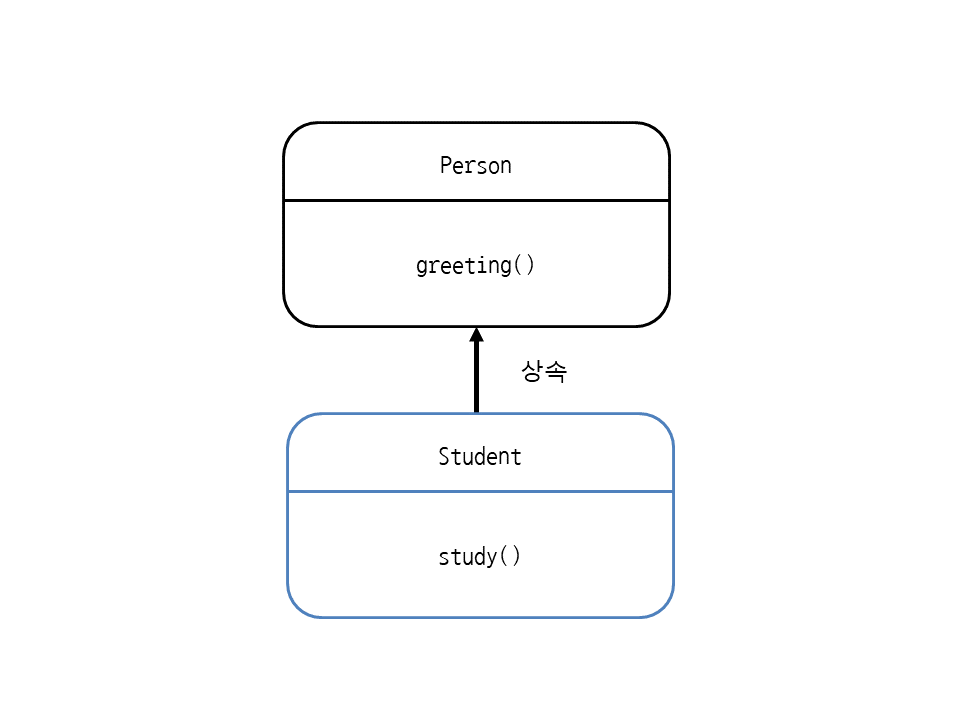

## 상속 확인하기

In [6]:
class Person():
    pass
class Student(Person):
    pass

issubclass(Student,Person)

True

## 상속 관계

In [ ]:
class Person:
    def greeting(self):
        print("안녕하세요")

class Student(Person):
    def study(self):
        print("공부하기")

여기서 학생 Student는 사람 Person이므로 같은 종류입니다. 이처럼 상속은 명확하게 같은 종류이며 동등한 관계일 때 사용합니다. 즉, "학생은 사람이다."라고 했을 때 말이 되면 동등한 관계입니다. 그래서 상속 관계를 영어로 is-a 관계라고 부릅니다(Student is a Person).

## 포함관계

In [7]:
class Person():
    def greeting(self):
        print("안녕하세요")

class PersonList():
    def __init__(self):
        self.person_list = []
    
    def append_person(self,person):
        self.person_list.append(person)

In [9]:
lists = PersonList()
james = Person()
maria = Person()

lists.append_person(james)

## 부모클래스 속성 사용하기

In [ ]:
class Person():
    def __init__(self):
        print('Person __init__')
        self.hello = "안녕하세요"
    
class Student(Person):
    def __init__(self):
        print("Student __init__")
        self.school = "파이썬 코딩 도장"

james = Student() #Student __init__
print(james.school) #파이썬 코딩 도장
print(james.hello) #에러


Student __init__
파이썬 코딩 도장


AttributeError: 'Student' object has no attribute 'hello'

## super()로 기반 클래스 초기화하기

In [ ]:
class Person():
    def __init__(self):
        print('Person __init__')
        self.hello = "안녕하세요"
    
class Student(Person):
    def __init__(self):
        print("Student __init__")
        super().__init__()

        self.school = "파이썬 코딩 도장"

james = Student() #Student __init__
        #super    # Person__init__
print(james.school) #파이썬 코딩 도장
print(james.hello) # 안녕하세요


Student __init__
Person __init__
파이썬 코딩 도장
안녕하세요


## 기반 클래스를 초기화하지 않아도 되는 경우

In [16]:
class Person():
    def __init__(self):
        print('Person__init__')
        self.hello = '안녕'

class Student(Person):
    pass

james = Person()
print(james.hello)

Person__init__
안녕


## 메서드 오버라이딩

In [17]:
class Person:
    def greeting(self):
        print("안녕")

class Student(Person):
    def greeting(self):
        print("안녕 나는 코딩 도장 학생")

james = Person()
james.greeting()

안녕


In [19]:
class Person:
    def greeting(self):
        print("안녕")

class Student(Person):
    def greeting(self):
        print("안녕 나는 코딩 도장 학생")

james = Student()
james.greeting()

안녕 나는 코딩 도장 학생


In [18]:
class Person:
    def greeting(self):
        print('안녕하세요.')
 
class Student(Person):
    def greeting(self):
        super().greeting()    # 기반 클래스의 메서드 호출하여 중복을 줄임
        print('저는 파이썬 코딩 도장 학생입니다.')
 
james = Student()
james.greeting()

안녕하세요.
저는 파이썬 코딩 도장 학생입니다.


## 다중 상속 사용

In [21]:
class Person:
    def greeting(self):
        print("안녕")

class University:
    def manage_credit(self):
        print("학점 관리")

class Undergraduate(Person, University):
    def study(self):
        print("공부하기")

james = Undergraduate()
james.greeting()
james.manage_credit()
james.study()

안녕
학점 관리
공부하기


## 다이이몬드 상속

In [23]:
class A:
    def greeting(self):
        print('안녕하세요. A입니다.')
 
class B(A):
    def greeting(self):
        print('안녕하세요. B입니다.')
 
class C(A):
    def greeting(self):
        print('안녕하세요. C입니다.')
 
class D(B, C):
    pass
 
x = D()
x.greeting()    # 안녕하세요. B입니다.
x.greeting()

안녕하세요. B입니다.
안녕하세요. B입니다.


In [24]:
D.mro()

[__main__.D, __main__.B, __main__.C, __main__.A, object]

MRO에 따르면 D의 메서드 호출 순서는 자기 자신 D, 그 다음이 B입니다. 따라서 D로 인스턴스를 만들고 greeting을 호출하면 B의 greeting이 호출됩니다

## 추상클래스

In [31]:
from abc import *

class StudentBase(metaclass=ABCMeta):
    @abstractmethod
    def study(self):
        pass
    
    @abstractmethod
    def go_to_school(self):
        pass

class Student(StudentBase):
    def study(self):
        print('공부하기')

james = Student()
james.study()

TypeError: Can't instantiate abstract class Student without an implementation for abstract method 'go_to_school'

In [33]:
from abc import *

class StudentBase(metaclass=ABCMeta):
    @abstractmethod
    def study(self):
        pass
    
    @abstractmethod
    def go_to_school(self):
        pass

class Student(StudentBase):
    def study(self):
        print('공부하기')

    def go_to_school(self):
        print("학교가기")

james = Student()
james.study()
james.go_to_school()

공부하기
학교가기
